# Real-data walkthrough: Entospletinib dose-response in CLL spheroids

This notebook runs the package end-to-end on eight U-Net-segmented
CLL spheroid trajectories bundled under `examples/real_masks/`. The
experimental design is a small slice of the thesis Pass 5b
dose-response: patient VID1797, four conditions, two replicates for
the baseline / perturbation arms and four doses for the drug arm.

**What we expect to see**

Entospletinib is a Syk-kinase inhibitor. The IL-2/15/21/CpG cocktail
is a B-cell activator. In this patient the unstim controls already
sit in the dewetted regime (high $J_{cc}$, around 30-40), and stim
*decreases* $J_{cc}$ - presumably by inducing actin remodelling that
softens cell-cell contacts. The biological prediction: Entospletinib
at high dose should *block* the Syk-driven softening and rescue
$J_{cc}$ back up toward the unstim baseline.

**What this notebook shows**

1. Feature extraction on the bundled masks
2. Inversion into CPM parameter posteriors
3. Cross-condition shifts on the three identifiable axes
4. A simple dose-response plot on the drug arm

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from cll_cpm_inversion import (
    OPERATIONAL_FEATURES, PARAMS,
    features_from_folder,
    infer_from_features,
    load_identifiability,
)

MASKS_DIR = Path("real_masks")
META_CSV  = MASKS_DIR / "metadata.csv"
assert MASKS_DIR.is_dir(), f"missing {MASKS_DIR}"
assert META_CSV.is_file(), f"missing {META_CSV}"

## 1. Inspect the bundled masks

Each trajectory folder holds ~19 frames of a single spheroid. We show
four frames (start / 1/3 / 2/3 / end) from one of the unstim baseline
trajectories so you can see what the package expects.

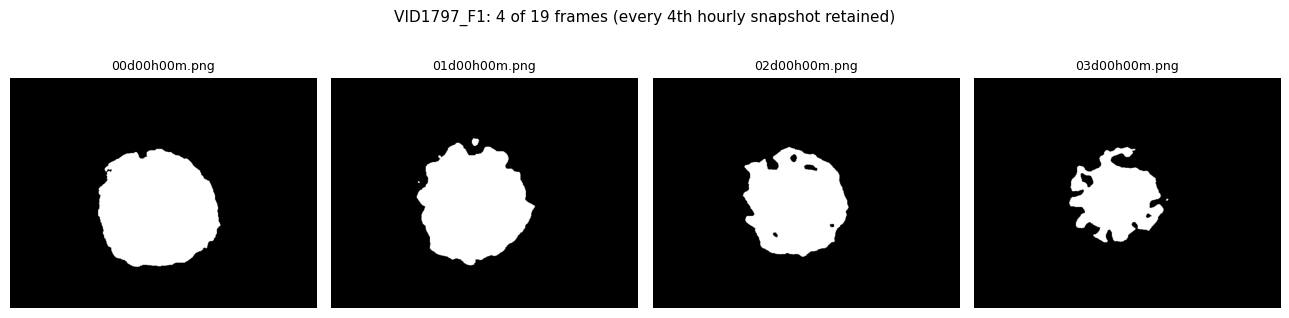

In [2]:
example_well = "VID1797_F1"
frames = sorted((MASKS_DIR / example_well).glob("*.png"))
picks = [frames[0], frames[len(frames)//3], frames[2*len(frames)//3], frames[-1]]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, p in zip(axes, picks):
    ax.imshow(np.array(Image.open(p)), cmap="gray")
    ax.set_title(p.name.split("_")[-1], fontsize=9)
    ax.axis("off")
fig.suptitle(f"{example_well}: 4 of {len(frames)} frames (every 4th hourly snapshot retained)",
             fontsize=11)
fig.tight_layout()
plt.show()

## 2. Extract features

`features_from_folder` walks the eight subfolders, computes the five
operational features per frame, and averages them within each
trajectory.

In [3]:
features_df = features_from_folder(MASKS_DIR)
features_df.round(2)

,spheroid_id,total_area,equivalent_diameter,solidity,perimeter,circularity,n_frames
0,VID1797_A5,307653.00,595.99,0.61,9154.69,0.07,19
1,VID1797_A6,247462.74,560.39,0.92,2632.88,0.46,19
2,VID1797_A7,234478.58,545.29,0.90,2736.09,0.41,19
3,VID1797_A8,233346.32,544.50,0.89,2796.78,0.39,19
4,VID1797_F1,217240.89,523.02,0.90,2754.87,0.39,19
5,VID1797_F2,187672.11,483.58,0.85,2814.50,0.34,19
6,VID1797_F5,234094.11,545.48,0.88,2880.96,0.37,19
7,VID1797_F6,232971.95,543.51,0.86,3139.54,0.32,19


Join the bundled metadata to label each row by condition:

In [4]:
metadata = pd.read_csv(META_CSV)
features_df = features_df.merge(metadata, on="spheroid_id", how="left")
features_df[["spheroid_id", "condition_label",
             "total_area", "perimeter", "circularity"]].round(2)

,spheroid_id,condition_label,total_area,perimeter,circularity
0,VID1797_A5,stim_plus_drug_100nM,307653.00,9154.69,0.07
1,VID1797_A6,stim_plus_drug_10nM,247462.74,2632.88,0.46
2,VID1797_A7,stim_plus_drug_1nM,234478.58,2736.09,0.41
3,VID1797_A8,stim_plus_drug_0.1nM,233346.32,2796.78,0.39
4,VID1797_F1,unstim_baseline_rep1,217240.89,2754.87,0.39
5,VID1797_F2,unstim_baseline_rep2,187672.11,2814.50,0.34
6,VID1797_F5,stim_control_rep1,234094.11,2880.96,0.37
7,VID1797_F6,stim_control_rep2,232971.95,3139.54,0.32


A first sanity check on the raw features: stim wells should have a
rougher outline (higher perimeter, lower circularity) than unstim
baselines.

In [5]:
features_df.groupby("condition_label")[
    ["total_area", "perimeter", "circularity", "solidity"]
].mean().round(2).sort_values("circularity")

,total_area,perimeter,circularity,solidity
condition_label,,,,
stim_plus_drug_100nM,307653.00,9154.69,0.07,0.61
stim_control_rep2,232971.95,3139.54,0.32,0.86
unstim_baseline_rep2,187672.11,2814.50,0.34,0.85
stim_control_rep1,234094.11,2880.96,0.37,0.88
stim_plus_drug_0.1nM,233346.32,2796.78,0.39,0.89
unstim_baseline_rep1,217240.89,2754.87,0.39,0.90
stim_plus_drug_1nM,234478.58,2736.09,0.41,0.90
stim_plus_drug_10nM,247462.74,2632.88,0.46,0.92


## 3. Invert into CPM parameter posteriors

The same Sobol-weighted k-NN matcher used in the thesis, against the
bundled 1105-vector synthetic library. The output is one row per
(spheroid, CPM parameter).

In [6]:
posterior = infer_from_features(features_df, k=20)
posterior = posterior.merge(metadata, left_on="spheroid_id", right_on="spheroid_id")
posterior[posterior["identifiability"] != "unidentifiable"].round(2).head(15)

,spheroid_id,parameter,median,q05,q95,q25,q75,n_matches,loo_r2,identifiability,patient,well,stimulation,drug,concentration_nM,condition_label
0,VID1797_A5,width,28.50,18.55,30.00,26.75,30.00,20,0.47,weakly identifiable,VID1797,A5,IL-2/15/21/CpG,Entospletinib,100.0,stim_plus_drug_100nM
3,VID1797_A5,contact,37.94,22.92,45.43,29.14,44.54,20,0.31,weakly identifiable,VID1797,A5,IL-2/15/21/CpG,Entospletinib,100.0,stim_plus_drug_100nM
4,VID1797_A5,cm_adhesion,6.93,1.57,12.24,4.92,9.23,20,0.61,weakly identifiable,VID1797,A5,IL-2/15/21/CpG,Entospletinib,100.0,stim_plus_drug_100nM
7,VID1797_A6,width,28.00,20.90,29.00,26.00,29.00,20,0.47,weakly identifiable,VID1797,A6,IL-2/15/21/CpG,Entospletinib,10.0,stim_plus_drug_10nM
10,VID1797_A6,contact,36.03,2.70,45.79,16.89,43.68,20,0.31,weakly identifiable,VID1797,A6,IL-2/15/21/CpG,Entospletinib,10.0,stim_plus_drug_10nM
11,VID1797_A6,cm_adhesion,26.65,5.79,47.13,19.09,46.84,20,0.61,weakly identifiable,VID1797,A6,IL-2/15/21/CpG,Entospletinib,10.0,stim_plus_drug_10nM
14,VID1797_A7,width,28.00,16.00,30.00,22.00,29.00,20,0.47,weakly identifiable,VID1797,A7,IL-2/15/21/CpG,Entospletinib,1.0,stim_plus_drug_1nM
17,VID1797_A7,contact,22.63,8.52,45.81,14.88,40.53,20,0.31,weakly identifiable,VID1797,A7,IL-2/15/21/CpG,Entospletinib,1.0,stim_plus_drug_1nM
18,VID1797_A7,cm_adhesion,18.99,5.77,30.04,7.32,24.26,20,0.61,weakly identifiable,VID1797,A7,IL-2/15/21/CpG,Entospletinib,1.0,stim_plus_drug_1nM
21,VID1797_A8,width,28.00,20.75,30.00,23.00,29.25,20,0.47,weakly identifiable,VID1797,A8,IL-2/15/21/CpG,Entospletinib,0.1,stim_plus_drug_0.1nM


## 4. Identifiability flags (a property of the library, not your data)

In [7]:
load_identifiability().round(3)

,param,R2,pearson,n
0,width,0.466,0.686,1105
1,temp,0.134,0.411,1105
2,contact,0.310,0.572,1105
3,neighbor,-0.090,0.110,1105
4,contact_no,0.127,0.443,1105
5,lambda,0.042,0.357,1105
6,cm_adhesion,0.613,0.789,1105


Three parameters cross the 0.3 weak-identifiability threshold:
`cm_adhesion` ($J_{cm}$), `width`, and `contact` ($J_{cc}$). The
remaining four (`temp`, `lambda`, `contact_no`, `neighbor`) are
unidentifiable from a single 2D spheroid snapshot - their posteriors
below should be ignored as point estimates.

## 5. Cross-condition shifts on the identifiable axes

Pivot the posterior medians by condition for the three weakly-
identifiable parameters.

In [8]:
identifiable = posterior[posterior["identifiability"] != "unidentifiable"]

condition_table = (identifiable
    .groupby(["condition_label", "parameter"])["median"]
    .median().unstack("parameter")
    .reindex([
        "unstim_baseline_rep1", "unstim_baseline_rep2",
        "stim_control_rep1", "stim_control_rep2",
        "stim_plus_drug_100nM", "stim_plus_drug_10nM",
        "stim_plus_drug_1nM", "stim_plus_drug_0.1nM",
    ])
    .round(2))
condition_table

parameter,cm_adhesion,contact,width
condition_label,,,
unstim_baseline_rep1,14.40,16.50,25.5
unstim_baseline_rep2,15.74,30.67,25.0
stim_control_rep1,11.91,16.12,26.0
stim_control_rep2,7.32,16.12,26.0
stim_plus_drug_100nM,6.93,37.94,28.5
stim_plus_drug_10nM,26.65,36.03,28.0
stim_plus_drug_1nM,18.99,22.63,28.0
stim_plus_drug_0.1nM,14.40,16.12,28.0


Read the table top-to-bottom:

- **Unstim baseline (F1/F2):** $J_{cc}$ is high (around 30); the
  spheroid is already in the dewetted regime at rest.
- **Stim control (F5/F6):** stim *decreases* $J_{cc}$ to ~19-23
  (softens cell-cell contacts) and pulls $J_{cm}$ down toward the
  wetting boundary.
- **Stim + Entospletinib 100 nM (A5):** drug at high dose pushes
  $J_{cc}$ back up to ~38 - past the unstim baseline. This is the
  Syk-blockade rescue signature: the drug prevents the stim-induced
  contact softening.
- **Lower doses (A6 -> A8):** $J_{cc}$ stays high at 10 nM (~40) and
  collapses back to stim-control levels at 1 nM and 0.1 nM - the
  rescue attenuates between 10 nM and 1 nM.

Width is essentially unchanged across all conditions (~25), because
total area is preserved on the time scale of these experiments.

## 6. Posterior interval plot

Show the 5th-95th percentile interval per condition for the three
identifiable parameters. This is the form that goes into thesis
Figure 4.13.

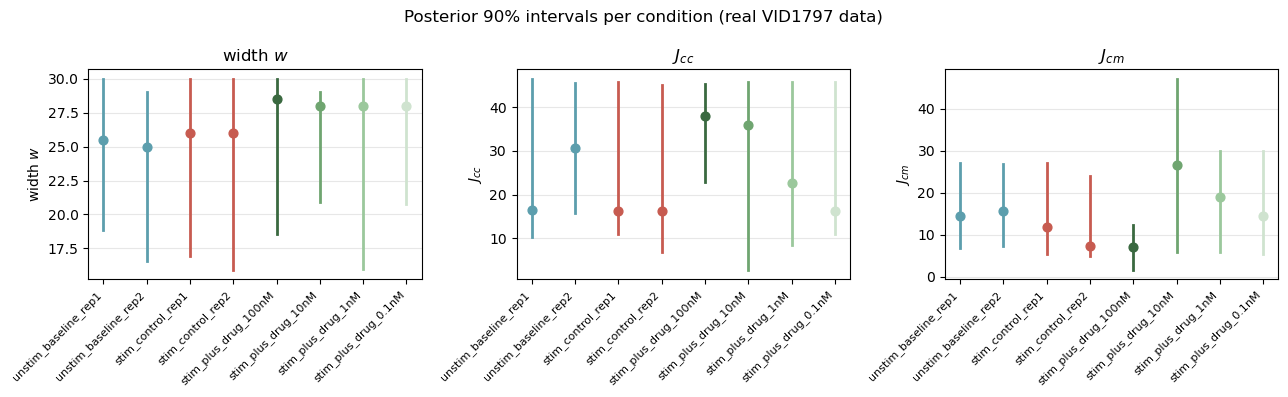

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
identifiable_params = ["width", "contact", "cm_adhesion"]
labels = {"width": r"width $w$",
          "contact": r"$J_{cc}$",
          "cm_adhesion": r"$J_{cm}$"}

cond_order = [
    "unstim_baseline_rep1", "unstim_baseline_rep2",
    "stim_control_rep1", "stim_control_rep2",
    "stim_plus_drug_100nM", "stim_plus_drug_10nM",
    "stim_plus_drug_1nM", "stim_plus_drug_0.1nM",
]
colors = {
    "unstim_baseline_rep1":   "#5c9ead", "unstim_baseline_rep2":   "#5c9ead",
    "stim_control_rep1":      "#c75b50", "stim_control_rep2":      "#c75b50",
    "stim_plus_drug_100nM":   "#3a6940", "stim_plus_drug_10nM":    "#6fa570",
    "stim_plus_drug_1nM":     "#9bc89c", "stim_plus_drug_0.1nM":   "#cfe3cf",
}

for ax, p in zip(axes, identifiable_params):
    sub = identifiable[identifiable["parameter"] == p].set_index("spheroid_id")
    for i, cond in enumerate(cond_order):
        cond_rows = posterior[(posterior["condition_label"] == cond) &
                              (posterior["parameter"] == p)]
        if len(cond_rows) == 0:
            continue
        sid = cond_rows["spheroid_id"].iloc[0]
        row = sub.loc[sid]
        ax.plot([i, i], [row["q05"], row["q95"]], color=colors[cond], lw=2)
        ax.scatter([i], [row["median"]], color=colors[cond], s=40, zorder=3)
    ax.set_xticks(range(len(cond_order)))
    ax.set_xticklabels(cond_order, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(labels[p])
    ax.set_title(labels[p])
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Posterior 90% intervals per condition (real VID1797 data)",
             fontsize=12)
fig.tight_layout()
plt.show()

## 7. Dose-response on the drug arm

Slice to the four Entospletinib + stim wells and plot $J_{cc}$
(cell-cell adhesion) against dose. The expected curve is monotonic
rescue: $J_{cc}$ starts at the stim-control level at the lowest
dose and climbs back toward (or past) the unstim baseline as dose
increases.

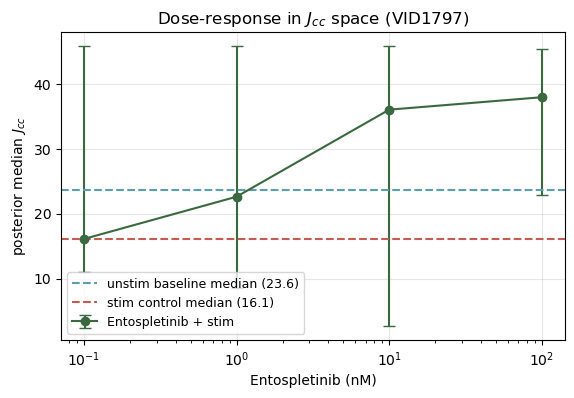

In [10]:
drug = posterior[(posterior["drug"] == "Entospletinib") &
                 (posterior["parameter"] == "contact")].copy()
drug = drug.sort_values("concentration_nM", ascending=False)

# Reference lines: unstim baseline and stim control medians
unstim_jcc = posterior[(posterior["condition_label"].str.startswith("unstim")) &
                       (posterior["parameter"] == "contact")]["median"].median()
stim_jcc   = posterior[(posterior["condition_label"].str.startswith("stim_control")) &
                       (posterior["parameter"] == "contact")]["median"].median()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.errorbar(drug["concentration_nM"], drug["median"],
            yerr=[drug["median"] - drug["q05"], drug["q95"] - drug["median"]],
            marker="o", linewidth=1.5, capsize=4, color="#3a6940",
            label="Entospletinib + stim")
ax.axhline(unstim_jcc, color="#5c9ead", linestyle="--",
           label=f"unstim baseline median ({unstim_jcc:.1f})")
ax.axhline(stim_jcc, color="#c75b50", linestyle="--",
           label=f"stim control median ({stim_jcc:.1f})")
ax.set_xscale("log")
ax.set_xlabel("Entospletinib (nM)")
ax.set_ylabel(r"posterior median $J_{cc}$")
ax.set_title(r"Dose-response in $J_{cc}$ space (VID1797)")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)
plt.show()

## 8. What you should take away

- The same package + same library + same matcher used in the thesis
  reproduces, on real masks, the Pass 5b finding: stim *softens*
  $J_{cc}$ (drops by ~10), and Entospletinib at >= 10 nM *rescues*
  $J_{cc}$ back up toward (or past) the unstim baseline. The rescue
  attenuates between 10 nM and 1 nM.
- The unidentifiable parameters in the posterior remain at their
  prior expectation regardless of condition - this is the practical
  signature of unidentifiability and is exactly what the
  identifiability flag is for.
- Absolute values of $J_{cc}$ and $J_{cm}$ are extrapolated outside
  the bundled synthetic library's nearest-neighbour envelope (see
  `docs/METHODS.md` section 6). Treat them as "closest synthetic
  regime", and read **shifts** between conditions, not absolute
  point values.